Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as your name and collaborators below: 


In [138]:
NAME = "Angelina Podolako"
STUDENT_NUMBER = "s1125886"

### Important: When handing in your homework:
- Hand in the notebook named as follows: Studentname_snumber.ipynb
- If you find any mistakes/have suggestions/like to complain about the material, please e-mail Emma at `emma.gerritse@ru.nl`
- Do not remove any cells in the notebook, as it might break the auto-grader
- When using platforms other than Jupyter Notebooks to make your assignments, it might remove the auto-grading metadata. To prevent this, please copy the answers back into the original notebook.
- Only type your answers in places where asked.   

To make sure your answers work correctly, please make sure to use the variable names as given in the assignment. This will look like:

```
    some_variablename = None

    # YOUR CODE HERE
    raise NotImplementedError()
```
You can remove the `raise NotImplementedError()` and answer the assignment as follows:

```
    some_variablename = None
    # YOUR CODE HERE
    your_code
    more_code
    some_variable = some_results
```

Not using the specified variable names may result in reduced points.

---

# Assignment 1: Math Refresh, Regression, Using data

## Deadline: September 18th, 23:59

In this assignment, we are going to do the following things:
- Refresh Numpy/Linalg knowledge
- Implement linear regression
- Take a look at the loss function
- Implement gradient descent
- Take a look at the real 

To pass this assignment, make sure to give all questions a serious try. If you at some point get stuck in part 2, you can continue to part 3. 

# Before you start:

Make sure that the following packages are installed:

```
pip install plotly>=5.9.0 numpy scikit-learn pandas
```

# Recommended part to make in week 1

## Numpy refreshers:

In the tutorial sessions, we will be using Numpy a lot. 

Numpy has most of its backend code written in C. This makes it much faster than Python! Often in Machine Learning, we will be handling large datasets. Programming in python is very convenient since many ML packages are written for it, however it's not very fast. By using Numpys C backend, we can speed things up by a factor of 100. That's the difference between waiting a day or 14 minutes for a piece of code to run. So please use the built-in Numpy functions as much as you can. 

Let's look at the use of Numpy with some examples:

### Exercise 1.1


Use the [numpy random normal](https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html) 

function to generate a random array with variable name `random` of length 1000000, mean of 0 and standard deviation of 1. 

In [184]:
import numpy as np

np.random.seed(seed=42)  # Random seed to make all answers reproducible

M = 1000000
mu = 0
sigma = 1
random = None
# YOUR CODE HERE
random = np.random.normal(mu, sigma, M)

In [185]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.2.a

First, use a _Regular Python for-loop_ to compute the sum of _random_

In [186]:
import time

start = time.time()

sum_random = 0
# YOUR CODE HERE
for i in random:
    sum_random += i 

end = time.time()
forloop_sumtime = end - start

# Comment: f-strings are really useful for printing things. If you've never seen them before, check out the documentation
# https://docs.python.org/3/tutorial/inputoutput.html
# In short, put your variable between the {} brackets
# And :.3f means 'round off this float on 3 decimals'
print(f"Summed to {sum_random:.1f} in {forloop_sumtime:.3f} seconds using a forloop")

Summed to -1599.8 in 0.198 seconds using a forloop


### Exercise 1.2.b

Use the [Numpy Sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) function to compute the sum of random

In [187]:
start = time.time()

sum_numpy = 0

# YOUR CODE HERE
sum_numpy = np.sum(random)

end = time.time()

numpy_sumtime = end - start 
print(
    f"Summed to {sum_numpy:.1f} in {numpy_sumtime:.4f} seconds. This is {forloop_sumtime/numpy_sumtime:.2f} times faster than the forloop time"
)

Summed to -1599.8 in 0.0020 seconds. This is 98.86 times faster than the forloop time


In [188]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

As you can see, using the built-in Numpy functions is much faster! For every piece of code you write, try looking for a built-in Numpy function that does exactly that thing.

Here are some that might be handy:

Note: In many places of this course, we will encourage you to figure out how certain functions work _from the documentation_. In machine learning, new libraries are being made every day, so learning how to read documentation is a very valuable skill.

### Making new matrices: 

[Linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) , [Arange](https://numpy.org/doc/stable/reference/generated/numpy.arange.html): Return evenly spaced numbers over a specified interval.

[Ones](https://numpy.org/doc/stable/reference/generated/numpy.ones.html) , [Zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html) and [Eye](https://numpy.org/devdocs/reference/generated/numpy.eye.html): Create matrices filled with ones, zeros, or the identity matrix 

### Making matrices from existing matrices: 

[Concatenate](https://numpy.org/doc/stable/reference/generated/numpy.concatenate.html): Concatenate two matrices

[Reshape](https://numpy.org/doc/stable/reference/generated/numpy.reshape.html) : Change the dimensions, for example from a 1x6 matrix to a 2x3 matrix. 

### Common matrix operations

[Matmul](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html) : Matrix multiplication

[Transposing](https://numpy.org/doc/stable/reference/generated/numpy.transpose.html) :  Transposing a matrix

[Sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) : Taking the sum of a matrix

[Mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) : Compute the mean of a matrix

[Square](https://numpy.org/doc/stable/reference/generated/numpy.square.html) : Pointwise squaring of all elements

[Multiply](https://numpy.org/doc/stable/reference/generated/numpy.multiply.html) : Pointwise multiplying elements of two arrays. (so $ \begin{pmatrix}
2 & 3 \\
\end{pmatrix} \cdot  \begin{pmatrix}
5 & 7 \\
\end{pmatrix} = \begin{pmatrix}
10 & 21 \\
\end{pmatrix}$ )

Open all of these and familiarize yourself with them. 


### Exercise 1.3

Just like with linear algebra, the _shape_ or _dimensions_ of matrices are important. 

Remember that we can make a vector in NumPy by using `np.array()` 
In these assignments, since we will have to do matrix multiplications, it's important to keep the dimensions in mind. 

Let's look at the following vectors and matrices $A$, $B$ and $C$. :
Use [numpy's shape](https://numpy.org/doc/stable/reference/generated/numpy.shape.html) function to figure out their **shape** or **dimensions**. 
Check the dimensions of the following matrix multiplications. If they are not valid, leave the variable as `None`. :
- $A \cdot C$
- $B \cdot C$
- $C \cdot C$
- $A.T \cdot A$
- $A \cdot A.T$




In [189]:
A = np.array([[1], [2], [3]])
B = np.array([[1, 2, 3]])
C = np.array([1, 2, 3])

In [190]:
# Use this cell to do your calculations
# A is 2d, B is 2d, C is 1d
B_shape = np.shape(B)  # Use this variable for the shape of B
C_shape = np.shape(C)  # Use this variable for the shape of C
A_C_shape = None  # A*C is not possible because the sizes A and C are not compatible 
B_C_shape = np.shape(np.multiply(B, C))  # B*C is possible because B and C are compatible in terms of the number of columns
C_C_shape = np.shape(np.square(C))  # Use this variable for the shape of C*C
AT_A_shape = np.shape(np.matmul(np.transpose(A), A))  # Use this variable for the shape of A^T*A
A_AT_shape = np.shape(np.matmul(A, np.transpose(A)))   # Use this variable for the shape of A*A^T

print(f"B_shape = {B_shape}\n"
      f"C_shape = {C_shape}\n"
      f"A_C_shape = {A_C_shape}\n"
      f"B_C_shape = {B_C_shape}\n"
      f"C_C_shape = {C_C_shape}\n"
      f"AT_A_shape = {AT_A_shape}\n"
      f"A_AT_shape = {A_AT_shape}")

B_shape = (1, 3)
C_shape = (3,)
A_C_shape = None
B_C_shape = (1, 3)
C_C_shape = (3,)
AT_A_shape = (1, 1)
A_AT_shape = (3, 3)


In [191]:
# Example answer:
A_shape = (3, 1)
A_A_shape = None
A_B_shape = (3, 3)

# Variables to use in your answer
B_shape = None  # Use this variable for the shape of B
C_shape = None  # Use this variable for the shape of C
A_C_shape = None  # Use this variable for the shape of A*C
B_C_shape = None  # Use this variable for the shape of B*C
C_C_shape = None  # Use this variable for the shape of C*C
AT_A_shape = None  # Use this variable for the shape of A^T*A
A_AT_shape = None  # Use this variable for the shape of A*A^T

# YOUR CODE HERE
B_shape = (1, 3)
C_shape = (3,)
A_C_shape = (3, 3)
B_C_shape = None
C_C_shape = (3,)
AT_A_shape = (1, 1)
A_AT_shape = (3, 3)

In [192]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""

'DO NOT MODIFY THIS CELL'

### Exercise 1.4
Solve the exercises below, given:
$ A = \begin{pmatrix}
5 & 0 & 7
\end{pmatrix} \  , B = \begin{pmatrix}
3 & 11 & 13
\end{pmatrix},\  c = 3, \ d = 5$

You should be able to solve all of them with _one line_ of code. You can solve all assignments using the NumPy functions given above and _without_ using for-loops, list comprehensions, or accessing individual elements of the arrays.
#### Exercise 1.4.a
Create the following matrix:
$$ E = \begin{pmatrix}
0 & 0 & 0\\
0 & 0 & 0
\end{pmatrix} $$

#### Exercise 1.4.b
Compute the sum of all even natural numbers starting with 0 up to and including 20

#### Exercise 1.4.c
Compute the mean of all even natural numbers starting with 0 up to and including 20

#### Exercise 1.4.d
Given $A$ as above, compute $A^T$

#### Exercise 1.4.e
Given the matrix $A$ as above with elements $\begin{pmatrix}
a_1 & a_2 & a_3
\end{pmatrix}$ and the constants $c,d$, compute 
$$F = \begin{pmatrix} c\cdot a_1 + d & c\cdot a_2 +d & c\cdot a_3 + d \end{pmatrix} $$

#### Exercise 1.4.f
Given a vector $A$ with elements $\begin{pmatrix}
a_1 & a_2 & a_3
\end{pmatrix}$ and $B = \begin{pmatrix} b_1 & b_2& b_3 \end{pmatrix}$, compute :
$$G =  (a_1\cdot b_1, a_2\cdot b_2, a_3\cdot b_3)$$

#### Exercise 1.4.g
Using matrix multiplication and transposition, compute $h = a_1\cdot b_1 + a_2 \cdot b_2 + a_3 \cdot b_3$

#### Exercise 1.4.h
Given a vector A with elements $\begin{pmatrix}
a_1 & a_2 & a_3
\end{pmatrix}$, compute  the pointwise squared matrix $$ I = \begin{pmatrix}
a_1^2 & a_2^2 & a_3^2
\end{pmatrix}$$

#### Exercise 1.4.j
Create an array $J$ starting from 0 to 10 with 35 elements evenly spaced out

#### Exercise 1.4.k
Arrange them in a 5 x 7 matrix $K$:

#### Exercise 1.4.l
Reshape $A$ from a (1,n) to a (n,) vector called $L$

In [193]:
# Matrices given as above, do not change:

A = np.array([[5, 0, 7]])
B = np.array([[3, 11, 13]])
c = 3
d = 5

In [194]:
E = None  # (2,3) matrix of zeros
sum_20 = None  # Sum of all even numbers between 0 and 20
mean_20 = None  # Mean of all even numbers between 0 and 20
A_T = None  # Transposed matrix of A
F = None  # (c*a_1 + d, c*a_2 + d, c*a_3 + d)
G = None  # pointwise multiply
h = None  # a_1*b_1 + a_2*b_2 + a_3*b_3
I = None  # pointwise squared
J = None  # 35 elements starting from 0 to 10
K = None  # previous arranged in 5 x 7 matrix
L = None  # A reshaped to (n,) vector
# YOUR CODE HERE
E = np.zeros((2,3))  # (2,3) matrix of zeros
sum_20 = np.sum(np.arange(0, 21, 2))  # Sum of all even numbers between 0 and 20
mean_20 = np.mean(np.arange(0, 21, 2))  # Mean of all even numbers between 0 and 20
A_T = (np.transpose(A))  # Transposed matrix of A
F = np.add(np.multiply(A, c), d)  # (c*a_1 + d, c*a_2 + d, c*a_3 + d)
G = np.matmul(A,np.transpose(B))  # pointwise multiply
h = np.matmul(A,np.transpose(B))  # a_1*b_1 + a_2*b_2 + a_3*b_3
I = np.square(A)  # pointwise squared
J = np.linspace(0, 10, num=35)  # 35 elements starting from 0 to 10
K = np.reshape(J, (5, 7))  # previous arranged in 5 x 7 matrix
L = np.reshape(A, (3, ))  # A reshaped to (n,) vector

print("E =\n", E)
print("sum_20 =", sum_20)
print("mean_20 =", mean_20)
print("A_T =\n", A_T)
print("F =\n", F)
print("G =\n", G)
print("h =", h)
print("I =\n", I)
print("J =", J)
print("K =\n", K)
print("L =", L)

E =
 [[0. 0. 0.]
 [0. 0. 0.]]
sum_20 = 110
mean_20 = 10.0
A_T =
 [[5]
 [0]
 [7]]
F =
 [[20  5 26]]
G =
 [[106]]
h = [[106]]
I =
 [[25  0 49]]
J = [ 0.          0.29411765  0.58823529  0.88235294  1.17647059  1.47058824
  1.76470588  2.05882353  2.35294118  2.64705882  2.94117647  3.23529412
  3.52941176  3.82352941  4.11764706  4.41176471  4.70588235  5.
  5.29411765  5.58823529  5.88235294  6.17647059  6.47058824  6.76470588
  7.05882353  7.35294118  7.64705882  7.94117647  8.23529412  8.52941176
  8.82352941  9.11764706  9.41176471  9.70588235 10.        ]
K =
 [[ 0.          0.29411765  0.58823529  0.88235294  1.17647059  1.47058824
   1.76470588]
 [ 2.05882353  2.35294118  2.64705882  2.94117647  3.23529412  3.52941176
   3.82352941]
 [ 4.11764706  4.41176471  4.70588235  5.          5.29411765  5.58823529
   5.88235294]
 [ 6.17647059  6.47058824  6.76470588  7.05882353  7.35294118  7.64705882
   7.94117647]
 [ 8.23529412  8.52941176  8.82352941  9.11764706  9.41176471  9.70588235


In [195]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 1.5

NumPy also has some convenient tools for slicing and indexing, you can read about that [here](https://numpy.org/doc/stable/user/basics.indexing.html)

Given the matrix $M$, use slicing and indexing to get the following elements out of $M$:
Use $M$ in all of your answers

$$ M = \begin{pmatrix}
0 & 1 & 2 & 3\\
4 & 5 & 6 & 7 \\
8 & 9 & 10 & 11 \\
12 & 13 & 14 & 15
\end{pmatrix} $$

#### Exercise 1.5.a
$m1 = 0$ 

### Exercise 1.5.b
$m2 = 15$, hint: use negative indexes

### Exercise 1.5.c
$$ M3 = \begin{pmatrix}
0 & 1 & 2 & 3\\
\end{pmatrix} $$

### Exercise 1.5.d
$$ M4 = \begin{pmatrix}
0 & 2 \\
\end{pmatrix} $$

### Exercise 1.5.e
$$ M5 = \begin{pmatrix}
0 \\
4  \\
8  \\
12 
\end{pmatrix} $$

### Exercise 1.5.f
$$ M6 = \begin{pmatrix}
5 & 6 \\
9 & 10  \\
\end{pmatrix} $$

### Exercise 1.5.g
$$ M7 = \begin{pmatrix}
3 & 2 & 1 & 0\\
\end{pmatrix} $$

In [196]:
M = np.arange(0, 16).reshape((4, 4))

m1 = M
m2 = M
M3 = M
M4 = M
M5 = M
M6 = M
M7 = M

# YOUR CODE HERE
m1 = M[0, 0]
m2 = M[-1][-1] #same as [-1,-1]
M3 = M[0] #or M[0, :]
M4 = M[0, ::2] #M[0][ ::2] 
M5 = M[: , 0]
M6 = M[1:3, 1:3] #[index of rows sliced(indexes1,2), index of columns sliced(indexes1,2),]
M7 = M[0, ::-1] #[index of row, start:stop:step]

In [197]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Well done! You have made the recommended part for week 1! You can continue working on this set after having had the lecture in week 2. 

# Recommended part to make in week 2:
**What follows after will make use of the knowledge gained in _Lecture 2_ .**

**You can work ahead if you want to, but the TA's might now be able to answer your questions.**

### Exercise 2.1.1

In these sets of assignments, we implement our gradient descent! We will get started with a small toy dataset. 
This is often a good idea in practice, since our models can get fairly complicated and our datasets fairly big. Having small datasets will make the iterations of testing our algorithms easier, and will also make it easier to debug your code. 

First, let's make an example NumPy array `X` with shape (11,1); having 11 elements equally spaced from 0 up to and including 10. Make the NumPy array `y` with shape (11,), with numbers equally spaced from 4 up to and including 24. (Hint, use for example [numpy.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html) )

_note_ : It is important in this case for X to be in shape (11,1) instead of (11,). Otherwise, it will be difficult to use the same code for multiple dimensions. 


In [198]:
N = 11
X = None
y = None

# YOUR CODE HERE
X = np.linspace(0, 10, N).reshape(N, 1) #(array from 0 to 10 witj 10 el)(reshape to (11,1))
y = np.linspace(4, 24, N)

In [199]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

In [200]:
# Let's add a little bit of random noise to y, this will make it a little bit more effort to actually learn something.
np.random.seed(seed=42)
y = y + np.random.normal(0, 0.5, N) #(0=mean, 0.5=std, N=amount vars)

Great! Visualization is very important. 
There are many different libraries in Python for making plots. The most popular are [Matplotlib](https://matplotlib.org/) and its extension [Seaborn](https://seaborn.pydata.org/). My personal favorite one is [Plotly](https://plotly.com/). You are free to use whichever library you like for plotting; however, most examples shown will use Plotly. 

Let's make a plot of our generated data:

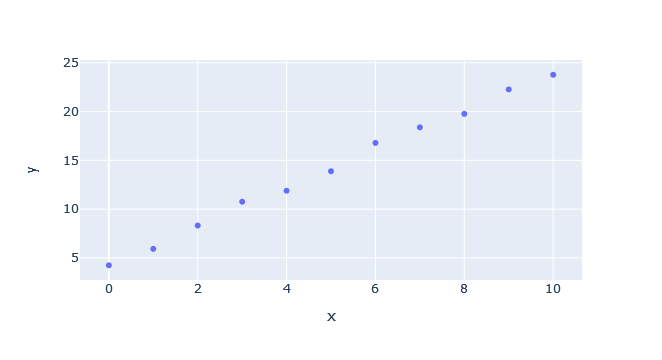

In [201]:
import plotly.express as px

fig = px.scatter(x=X.T[0], y=y) #X= 2D array, we use X.T[0] to flatten
fig.show()

### Exercise 2.1.2

What do you think will be the linear equation predicting this relationship? 

y = x  #h(x)=X⋅weight+bias,  weight = slope and bias = intercept of the linear model

Remember that in the lectures, we gave all code using the weight matrix $w$ and added a column with constant ones. This is common in _machine learning math language_. However, in _machine learning coding_ we will often write this weight for the constant as the _bias_ value.

So for example, given the dataset $X = (1, 2, 3)$ and $y = (8, 11, 14)$, we can express this using the function $h(x) = 5 + 3x$.

In _math language_, we would change the dataset $X$ to the dataset $X = ((1,1), (1,2), (1,3))$, we would use the weights $w = (5,3)$, and then express our hypothesis function as $h(x) =  X \cdot w$. This elegant and short notation makes it easier to derive proofs. 

In _coding_, it is not very efficient to add a column with only ones to your database. That is why, we will keep our database $X = (1, 2, 3)$, set our weights as $weights = (3)$ and have a bias value $bias = 5$. We will then write our hypothesis function as $h(x) = X \cdot weight + bias$


### Exercise 2.1.3

Make a function that given a matrix X of shape (N,m), a weight matrix of shape (m,1) and a float value bias, make the hypothesis function 

$h(x) = X\cdot weight+ bias$

Make sure the resulting vector has _the same shape as y_

In [202]:
def evaluate_set(X, weight, bias):
    # Input: X (dim (N,m)) , weight (dim (m,) ), bias (float)
    # Output: Output of the hypothesis function, dimensions (N,)
    # YOUR CODE HERE
    return np.dot(X, weight)+bias

In [203]:
# Test with the function you estimated
weight = np.array([2])
bias = 4
y_prime = evaluate_set(X, weight, bias)
print(X.shape)
print(weight.shape)
print(y.shape)
print(y_prime.shape)

(11, 1)
(1,)
(11,)
(11,)


In [204]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.4

Great! Now we want to see how well we did. For that, we will implement the least squared error.

$$J(w) = \frac{1}{2} \sum_i ( h_w(x^{(i)}) - y^{(i)} )^2$$

The squared error is a function that takes the results of the hypothesis function called `y_prime` and the true values of `y` as input and outputs a score (which is a floating point value).

Tip: try solving it again just using Numpy functions, without forloops. 


In [205]:
def least_squared_error(y_prime, y):
    # Input, two array lists of dimensions (N,)
    # Output: floating point value
    # YOUR CODE HERE
    return 0.5 * np.sum((y_prime - y)**2)

### Exercise 2.1.5

Given this least square function, a weight array and a bias value, compute the least squared error. Change around the values for weights and bias, and see how this impacts the least squared score.

In [206]:
weight = np.array([2])
bias = 4
least_squared = None
# YOUR CODE HERE
least_squared = least_squared_error(y_prime, y)

print(least_squared)

0.8658766260388056


In [207]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

Now, we can make a a plot of the error function using different weights.

For this, we will use a trick called a [mesh grid](https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html) . Mesh grids are a way of making a 2D coordinate system, which is useful for creating plots. 

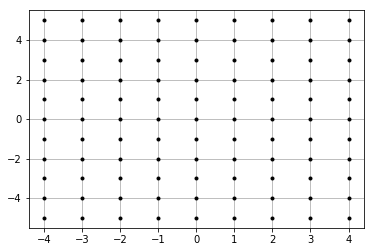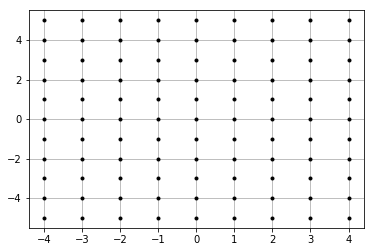

This will create two 2D arrays containing the X-value and the Y-value of the array.

We can then vectorize our least squared error function over these two mesh-grids, similar to how one would use the map function in Functional Programming.



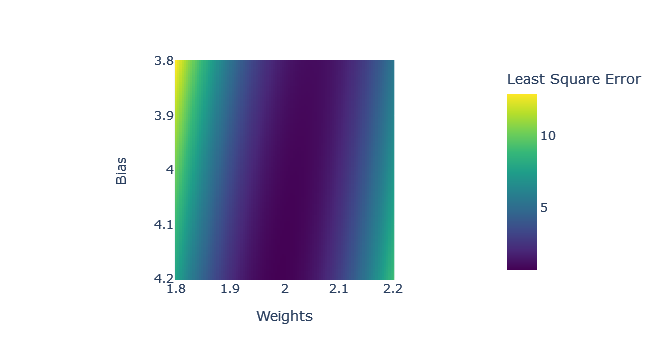

In [208]:
# First creating a linear space of the dimensions we want our plot to go over

weights_plot = np.linspace(1.80, 2.20, 101)
bias_plot = np.linspace(3.8, 4.2, 101)

# Next we will create our mesh grid, this will create two 2-D arrays. One contains the x-value,
# and one contains the y-value
ww, bb = np.meshgrid(weights_plot, bias_plot)


# np.vectorize is very similar to a map in functional programming, and allows us
# to be able to use any function on an entire array
@np.vectorize
def vectorized_LSE(weights, bias):
    return least_squared_error(evaluate_set(X, np.array([weights]), bias), y)


LSE = vectorized_LSE(ww, bb)


fig = px.imshow(
    LSE,
    x=weights_plot,
    y=bias_plot,
    color_continuous_scale="viridis",
    labels=dict(x="Weights", y="Bias", color="Least Square Error"),
)

fig.update_xaxes(title_text='Weights')
fig.update_yaxes(title_text='Bias')

fig.show()

### Exercise 2.1.6


By exploring the plot above, which values of x and y seem to be the best? 

Note: You do not have to write a function to find the result, you can just manually inspect the figure. 
The autograder will detect your answer as correct as long as you are 0.1 close. 

In [209]:
best_weight = None
best_bias = None

# YOUR CODE HERE
best_weight = 1.992
best_bias = 4.184

In [210]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.7

We have now seen the _feature space_ of this regression problem, we are now going to solve this using linear regression. For that, we first have to implement the function giving the _gradient_ of the least squared error. Remember that the gradient function for our Least Squared Error loss function

$$J(w) = \frac{1}{2} \sum_i ( h_w(x^{(i)}) - y^{(i)} )^2$$

Equals

$$\frac{\partial}{\partial  w_j } J(w) = \sum_i ( h_w(x^{(i)}) - y^{(i)} )\cdot x_j^{(i)}$$

Filling that in in the Gradient Descent algorithm

$$ w_j := w_j - \alpha \frac{\partial}{\partial  w_j } J(w)$$

This gives us our update rule for every step:

$$ w_j := w_j + \alpha \sum_i ( y^{(i)} - h_w(x^{(i)}))\cdot x_j^{(i)} $$

Complete the function for our gradient descent algorithm, by using the previously defined `evaluate_set` for $h(x)$. 

hint:
Since we split _weights_ and _bias_ into two separate variables, you also need to separately update them. 
Note that when updating bias, $x_0^{(i)} = 1$.

For each step, we should have something like

- Compute $\text{result} = y^{(i)} -  h_w(x^{(i)})$ (resulting in a np array of the same shape as y )

- weights = weight + .... (resulting in a np array in the same shape as weights)

- bias = bias + ... (resulting in a float)

To check if you implemented things correctly, print the shape of `result` and `weights` after each iteration, and start with a small number of iterations. 


In [211]:
def gradient_descent(x, y, lr, steps):
    N, dim = x.shape
    weights = np.ones((dim))
    bias = 0
    for i in range(steps):
        # YOUR CODE HERE
        y_prime = evaluate_set(x, weights, bias) #predicted y
        result = y - y_prime #difference between predicted and real data
        weights = weights + lr * np.dot(x.T, result) / N #gradient step to update weights
        bias = bias + lr * np.sum(result) / N
        print("Result:",result,"\n")
        print("Weight:",weights,"\n")
        print("Bias:",bias,"\n-----------------------------------------------")
    return weights, bias

### Exercise 2.1.8

Play around with the values of learning_rate and steps until you get an acceptable answer which is close to the values you found in 2.1.6. 
You can use this to check if your implementation is correct. 

In [212]:
learning_rate = 0.1
steps = 1

# YOUR CODE HERE
learning_rate = 0.0085
steps = 1500

p_weights, p_bias = gradient_descent(X, y, learning_rate, steps)
print(p_weights, p_bias)

Result: [ 4.24835708  4.93086785  6.32384427  7.76151493  7.88292331  8.88293152
 10.78960641 11.38371736 11.76526281 13.27128002 13.76829115] 

Weight: [1.47327973] 

Bias: 0.07805209745934039 
-----------------------------------------------
Result: [4.17030498 4.37953603 5.29923272 6.26362365 5.91175231 6.43848079
 7.87187595 7.99270718 7.9009729  8.93371038 8.95744179] 

Weight: [1.80244152] 

Bias: 0.13532636370882517 
-----------------------------------------------
Result: [4.11303071 3.99309997 4.58363486 5.218864   4.53783087 4.73539756
 5.83963092 5.63130036 5.21040428 5.91397997 5.60854959] 

Weight: [2.03124352] 

Bias: 0.17812442245825577 
-----------------------------------------------
Result: [4.07023265 3.7214999  4.0832328  4.48965993 3.57982479 3.54858948
 4.42402084 3.98688827 3.33719019 3.81196388 3.27773149] 

Weight: [2.19015801] 

Bias: 0.21083461254528355 
-----------------------------------------------
Result: [4.03752246 3.52987522 3.73269363 3.98020627 2.911456

In [213]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

### Exercise 2.1.9

Use these newly found values for weight and bias, predict the value of `y_prime`, and compute the least squared error for those values.
Change the values of learning_rate and steps above, until your least squared error gets smaller than 10.


In [214]:
current_error = None  ## Assign the result of least_squared_error to this variable

# YOUR CODE HERE
y_prime = evaluate_set(X, p_weights, p_bias)
current_error = least_squared_error(y_prime, y)
print(current_error)

0.6731531240056415


In [215]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""


'DO NOT MODIFY THIS CELL'

## Exercise 2.2.1: Testing on a real dataset:

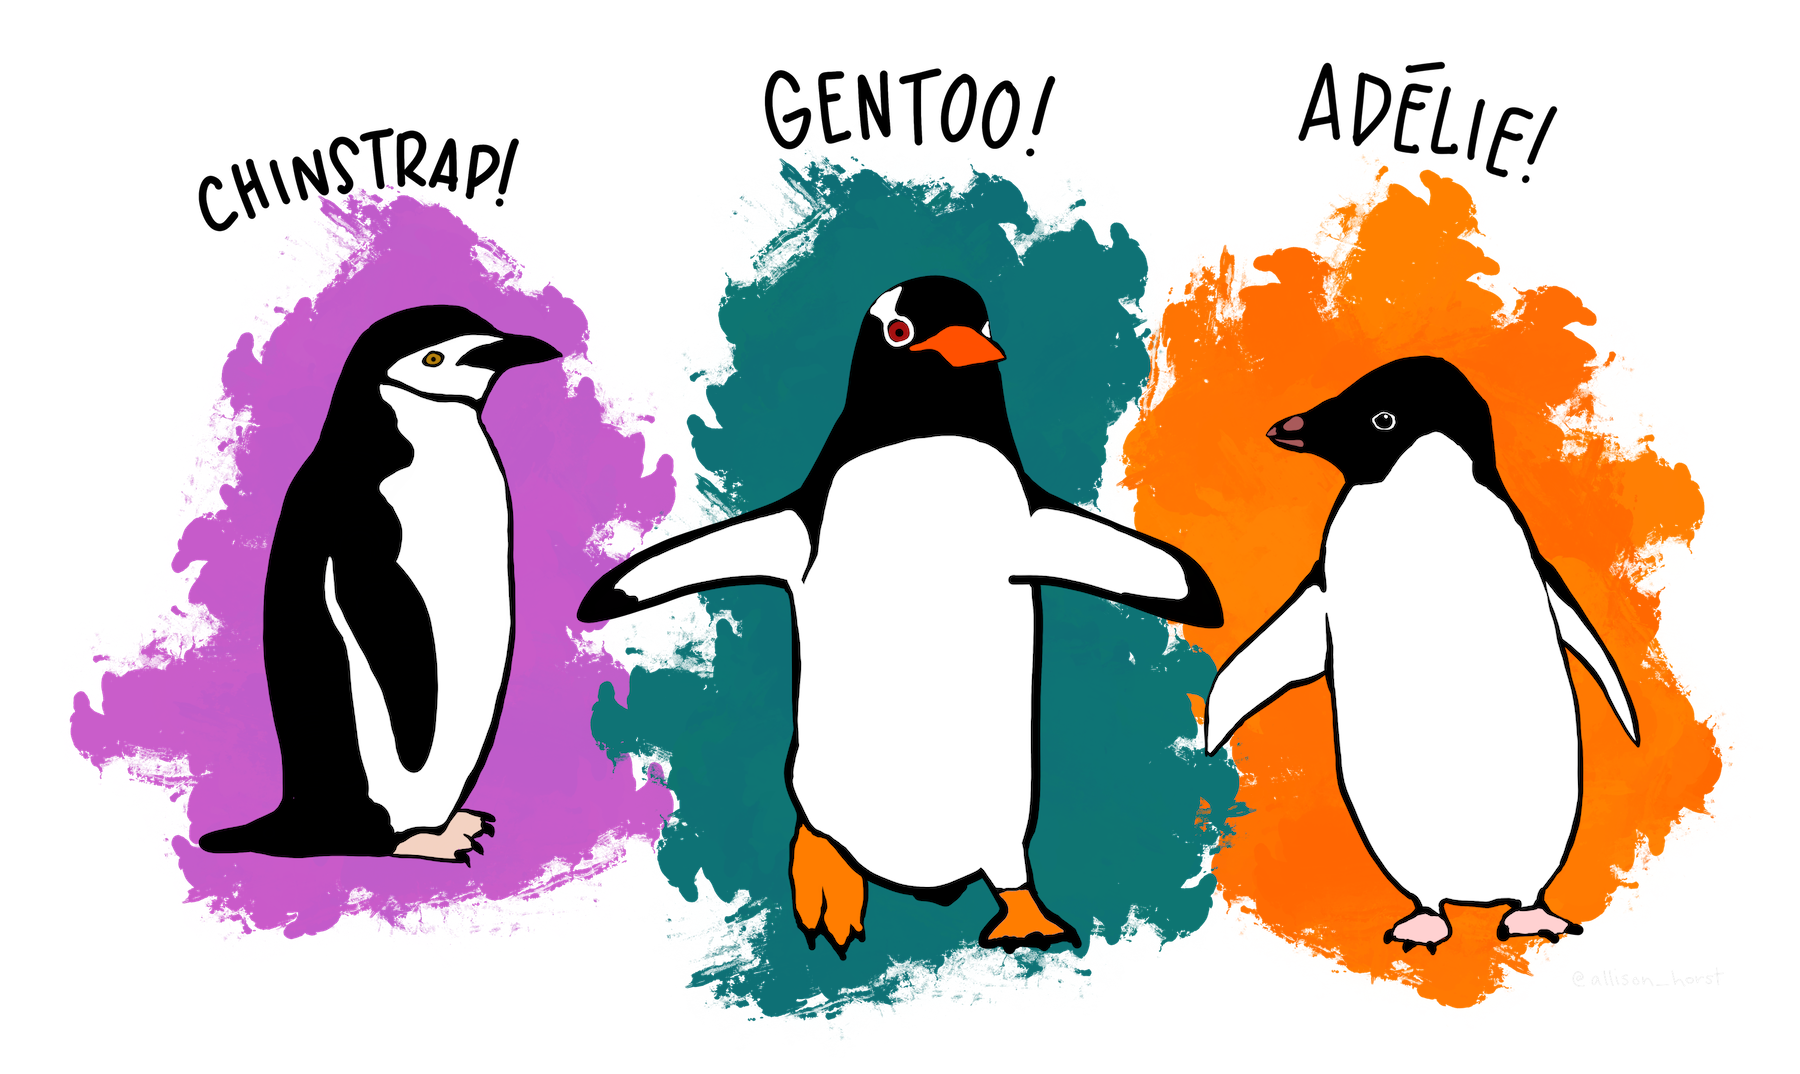!

Seems to work pretty well, hopefully! Let's test it on a real dataset! For this, we use the Penguin dataset, read more [here](https://github.com/allisonhorst/palmerpenguins).


In [216]:
# Downloading the penguin dataset using curl https://curl.se/docs/tutorial.html
!curl -o penguin.csv https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 13478  100 13478    0     0   218k      0 --:--:-- --:--:-- --:--:--  226k


In [217]:
# Loading the data
import pandas as pd

penguins = pd.read_csv("penguin.csv")
# To make our live easier, let's drop all the NaN values (We'll learn to deal with this later)
penguins = penguins.dropna()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


### Exercise 2.2.2
Plot the data using [plotly 3D plots](https://plotly.com/python/3d-scatter-plots/)

Play around trying to change things in the lay-out, coloring, or use of markers.

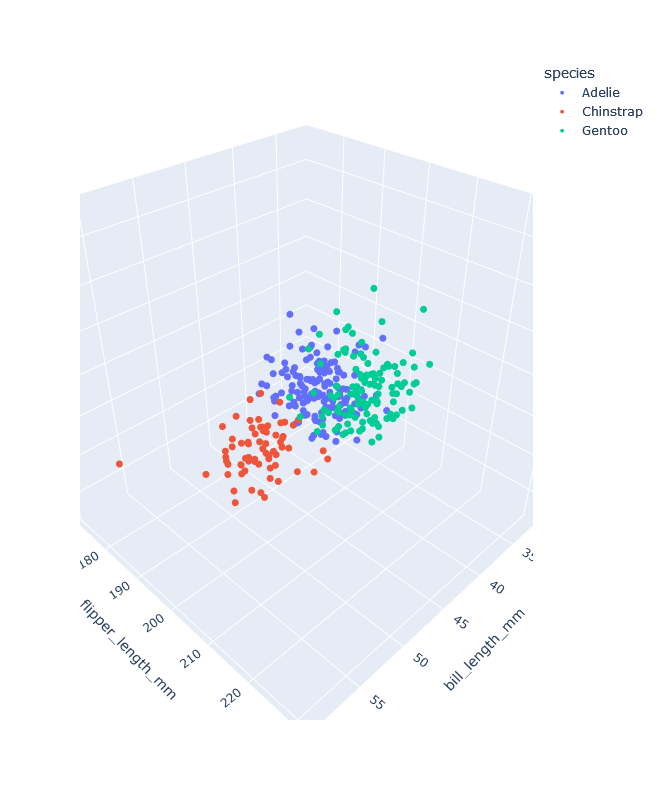

In [218]:
# Plotting the data in 3D:
# Try playing around with the parameters in the plot below:

# The following plots the pandas dataframe in 3D. You can immediately plug in the name of the columns


fig = px.scatter_3d(
    penguins,
    x="bill_length_mm",
    y="flipper_length_mm",
    z="body_mass_g",
    color="species",
)


# This line sets the shape and size of the markers
fig.update_traces(
    marker=dict(
        size=4,
    ),
    selector=dict(mode="markers"),
)

# This line sets the size for the plot
fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)

# This line shows the figure
fig.show()

### Exercise 2.2.3

Since we have three different species of Penguins, we see some possible correlation between bill length, body mass and flipper length. 
However, we also see that these three species of penguins are clearly separated within the plots. For that reason, let us just focus on the Gentoo penguins. 

For that, first make a dataframe called gentoo_penguins, in which we store the dataframe but only when the `species` column equals `Gentoo`. [Check how to filter dataframes here](https://pandas.pydata.org/docs/getting_started/intro_tutorials/03_subset_data.html)

Next, make 2 numpy arrays, the first one called `penguin_X`, which contains the $(N,2)$ array of the x_features 
`['bill_length_mm', 'flipper_length_mm']`, and the `penguin_y` which contains the $(N,)$ shaped NumPy array containing `['body_mass_g']`


In [219]:
gentoo_penguins = None
penguin_X = None
penguin_y = None

x_features = ["bill_length_mm", "flipper_length_mm"]
y_features = ["body_mass_g"]

# YOUR CODE HERE
gentoo_penguins =  penguins[penguins["species"] == "Gentoo"] #datasetname[dataset["column"]=="name"]
penguin_X = gentoo_penguins[x_features].to_numpy() #2d since to_numpy on dataframe 
penguin_y = gentoo_penguins[y_features].to_numpy().reshape(-1) #reshape to make it vector\1d array


# Note that the values for bill_length_mm are between 10 and 100, for flipper length are between 100 and 1000
# and for body_mass_g, the values are between 1000 and 10000. To make our life with gradient descent a little bit easier
# We will multiply the arrays with a value to make sure all our values are between 0.1 and 1
penguin_X = np.multiply(penguin_X, np.array([0.01, 0.001]))
penguin_y = penguin_y * 0.0001

In [220]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""



'DO NOT MODIFY THIS CELL'

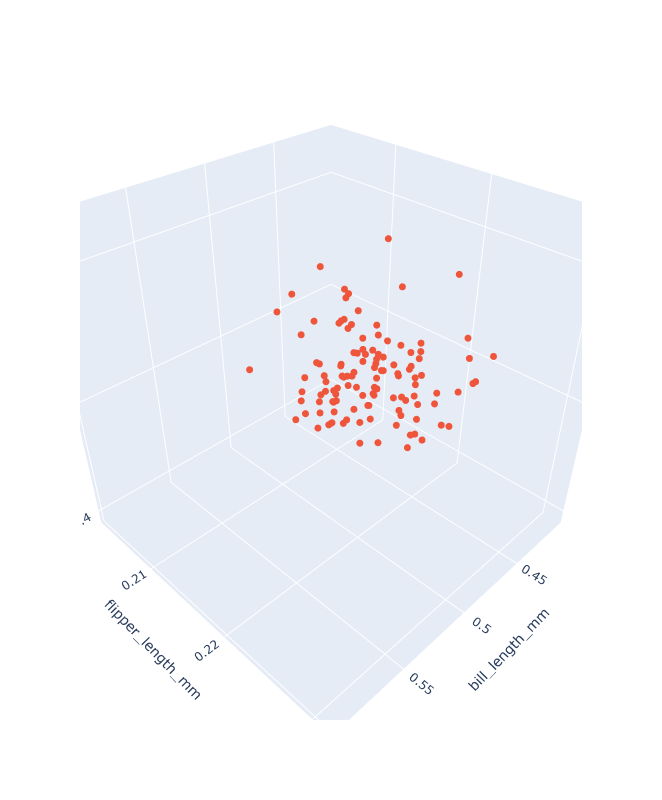

In [221]:
# Use this plot to inspect the values of penguin_X and penguin_y

fig = px.scatter_3d()
fig.add_scatter3d(
    x=penguin_X[:, 0], y=penguin_X[:, 1], z=penguin_y, mode="markers", name="True"
)

fig.update_traces(
    marker=dict(
        size=4,
    ),
    selector=dict(mode="markers"),
)

fig.update_scenes(
    xaxis=dict(title=x_features[0]),
    yaxis=dict(title=x_features[1]),
    zaxis=dict(title=y_features[0]),
)

fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)
fig.show()

### Exercise 2.2.4

Now we can do Gradient Descent to learn about the penguins! Use the function `gradient_descent` you created above, and try experimenting with `learning_rate` and `steps` to find a value for `penguin_weights` and `penguin_bias`. 
Are these values what you expected, given the plot above?



In [224]:
learning_rate = 1
steps = 1

# YOUR CODE HERE
learning_rate = 0.1
steps = 800

penguin_weights, penguin_bias = gradient_descent(
    penguin_X, penguin_y, learning_rate, steps
)

print(penguin_weights, penguin_bias)

Result: [-0.222  -0.16   -0.252  -0.148  -0.151  -0.22   -0.185  -0.166  -0.202
 -0.168  -0.158  -0.151  -0.204  -0.112  -0.248  -0.125  -0.215  -0.083
 -0.191  -0.174  -0.15   -0.166  -0.238  -0.173  -0.144  -0.166  -0.128
 -0.232  -0.165  -0.17   -0.167  -0.153  -0.221  -0.196  -0.164  -0.144
 -0.138  -0.213  -0.16   -0.24   -0.151  -0.233  -0.237  -0.172  -0.163
 -0.245  -0.19   -0.152  -0.137  -0.191  -0.175  -0.221  -0.226  -0.192
 -0.165  -0.216  -0.175  -0.195  -0.173  -0.241  -0.153  -0.231  -0.209
 -0.207  -0.158  -0.144  -0.185  -0.175  -0.218  -0.185  -0.193  -0.162
 -0.21   -0.136  -0.224  -0.131  -0.192  -0.08   -0.2405 -0.201  -0.2135
 -0.189  -0.186  -0.176  -0.192  -0.201  -0.1995 -0.196  -0.198  -0.21
 -0.192  -0.154  -0.174  -0.214  -0.2175 -0.2035 -0.2245 -0.211  -0.219
 -0.227  -0.1895 -0.169  -0.133  -0.157  -0.203  -0.1835 -0.14   -0.221
 -0.132  -0.183  -0.195  -0.2415 -0.196  -0.11   -0.1935 -0.198  -0.151
 -0.144  -0.172 ] 

Weight: [0.9912569  0.99601551] 

Bi

In [225]:
"""Checks whether previous output is correct"""
"""DO NOT MODIFY THIS CELL"""



'DO NOT MODIFY THIS CELL'

### Exercise 2.2.5

Predict the values of the weight of the penguins with the `evaluate_set` function, and plot the values of `penguin_X` together and add them to the plot below: 
Also use `current_error` to compute the least squared error, given `penguin_y` and the predicted weight values of the penguins. 

In [226]:
current_error = None # Assign the result of least_squared_error to this variable

# YOUR CODE HERE
y_prime = evaluate_set(penguin_X, penguin_weights, penguin_bias)
current_error = least_squared_error(y_prime, penguin_y)
print(current_error)

0.07358941933100904


In [227]:
"""DO NOT MODIFY THIS CELL"""



'DO NOT MODIFY THIS CELL'

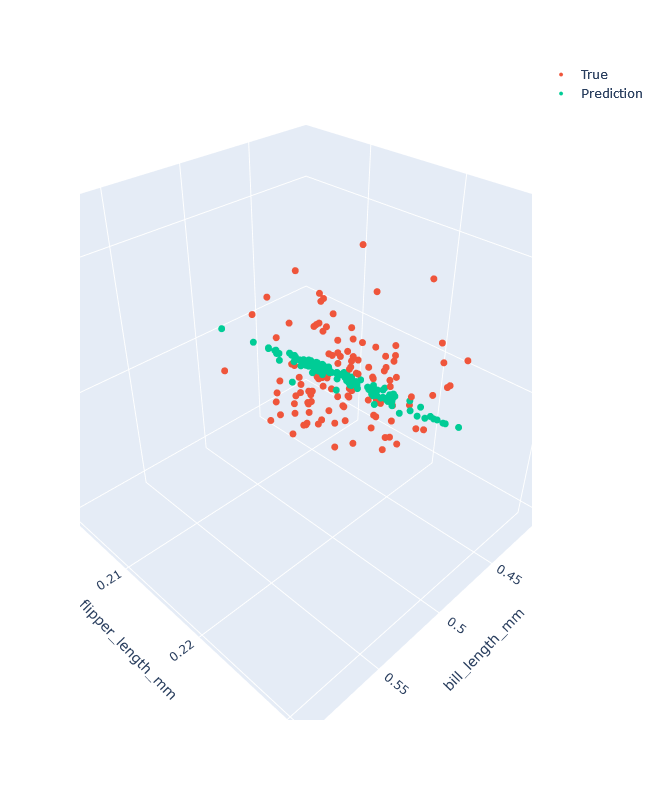

In [228]:
fig = px.scatter_3d()
fig.add_scatter3d(
    x=penguin_X[:, 0], y=penguin_X[:, 1], z=penguin_y, mode="markers", name="True"
)

# Add a trace with the predictions instead of the true values of y.
# YOUR CODE HERE
fig.add_scatter3d(
    x=penguin_X[:, 0], y=penguin_X[:, 1], z=y_prime, mode="markers", name="Prediction"
)



fig.update_traces(
    marker=dict(
        size=4,
    ),
    selector=dict(mode="markers"),
)

fig.update_scenes(
    xaxis=dict(title=x_features[0]),
    yaxis=dict(title=x_features[1]),
    zaxis=dict(title=y_features[0]),
)

fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)
fig.show()

### Exercise 3.1: The package

You have now implemented linear regression by hand. This has been a good exercise to further your understanding, however, whenever you use linear regression in the future, its best to use the official package. Careless mistakes can happen quickly, so using a carefully maintained package will reduce the chance of your research results being wrong.


For the last bit of the assignment, let us use the linear regression module in Sk Learn.
You can read up on it here, or use the `help` command on the function: 
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html



Use again as features for `X` `bill_length_mm` and `flipper_length_mm`, and as feature for `y` `body_mass_g`.
Make sure you have some np array in which you store the predicted values for `y`. 


In [229]:
from sklearn.linear_model import LinearRegression

# YOUR CODE HERE
X = penguins[["bill_length_mm", "flipper_length_mm"]].to_numpy() #.values is old alternative
y = penguins["body_mass_g"].to_numpy().reshape(-1) #.values is old alternative, but can stay data it dataframe not numpy

y_prime = LinearRegression().fit(X, y).predict(X) #create lin regres.teach it\fit. predict

print(y_prime)

[3206.61678791 3453.04868728 3897.02279424 3781.39244616 3647.61573412
 3205.62506766 3891.56833285 3265.4236822  3693.03440501 4015.42784239
 3389.77905186 3889.08903222 4005.71110055 3329.98043732 3876.39712963
 2857.94276387 3150.78505438 3581.86679807 3397.71281387 3156.23951576
 3481.11225377 3311.83407334 3506.89698031 2760.65924045 3164.6691379
 3061.9311531  3050.5263702  3550.82807082 3362.21134549 3877.68424933
 3940.45802463 3645.13643349 3173.09876004 3199.17888602 3356.75688411
 3242.61411641 3899.50209487 3435.69358287 3964.75517079 3391.76249236
 3649.10331449 3265.4236822  3631.25234997 3711.38122966 3453.5445474
 3553.80323158 3626.29374871 4149.90087524 3477.14537276 3706.91848853
 3450.56938665 3800.73099107 3193.72442464 3834.74487907 3385.31631072
 3901.9813955  3394.73765311 3754.32059993 3339.89763983 3756.79990055
 3873.2215082  3558.76183283 3630.75648984 4051.12977144 3618.85584682
 3649.59917462 3942.44146513 4022.0744847  3628.77304934 3909.41929738
 3704.43

### Exercise 3.2: The package
Make a plot similar to the plot in exercise `2.2.5`, where we plot two traces: `bill_length_mm` and `flipper_length_mm`, the true `body_mass_g` and the predicted value for `body_mass_g` you obtained in the last cell. 

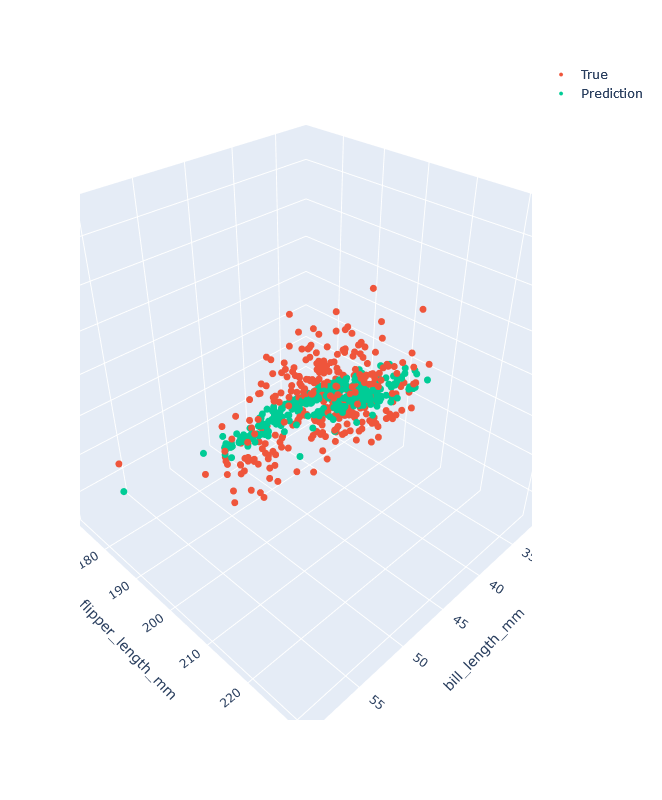

In [230]:
# YOUR CODE HERE
fig = px.scatter_3d()
fig.add_scatter3d(
    x=X[:, 0], y=X[:, 1], z=y, mode="markers", name="True"
)

# Add a trace with the predictions instead of the true values of y.
fig.add_scatter3d(
    x=X[:, 0], y=X[:, 1], z=y_prime, mode="markers", name="Prediction"
)



fig.update_traces(
    marker=dict(
        size=4,
    ),
    selector=dict(mode="markers"),
)

fig.update_scenes(
    xaxis=dict(title=x_features[0]),
    yaxis=dict(title=x_features[1]),
    zaxis=dict(title=y_features[0]),
)

fig.update_layout(
    autosize=False,
    width=800,
    height=800,
)
fig.show()